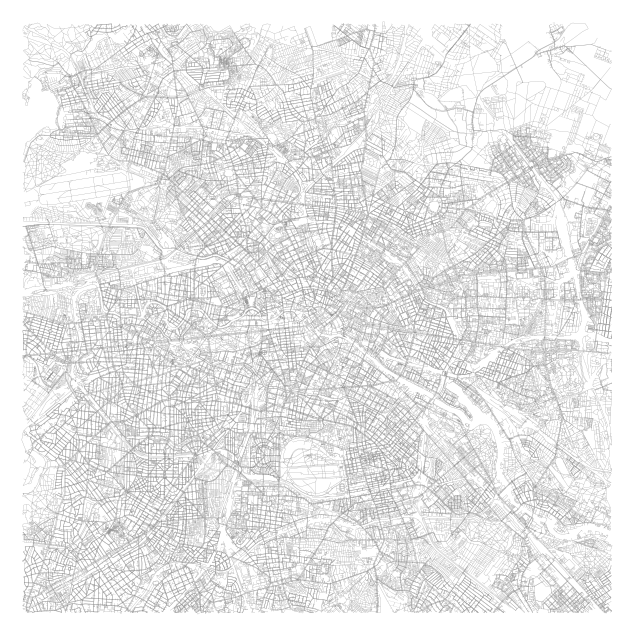

In [1]:
import osmnx as osm

berlin_rn = osm.graph_from_point((52.520008,13.404954), simplify = True, dist = 10000)

_,axis1 = osm.plot_graph(berlin_rn, node_size=0,edge_linewidth=0.09, bgcolor='white', show=True)


In [2]:
# parse the frequent maximal polylines
import os
import utm
class Trajectory:
    def __init__(self):
        self.points = []
        self.ids = []
        self.beginnings = {}
    
    def push_back(self, coords, id):
        if len(self.points)> 0:
            
            if id != self.ids[-1]:
                self.beginnings[id] = len(self.points) - 1
    
        else:
            self.beginnings[id] = 0
        
        self.points.append(coords)
        self.ids.append(id)
        
    
    def get_x_coord_at(self,idx):

        return self.points[idx][0]
    
    def get_y_coord_at(self,idx):

        return self.points[idx][1]
    
    # return list of tuples
    def get_pathlet_points(self, beginning, end, id)-> list:

        start_offset = self.beginnings[id] + beginning
        end_offset = self.beginnings[id] + end 

        l = []
        
        for i in range(start_offset, end_offset + 1):
            l.append(self.points[i])

        return l

def get_polyline_string(l) -> str:

    s = "MULTILINESTRING(("

    for i in range(0, len(l)):
        s += f"{l[i][1]} {l[i][0]}"

        if i < len(l) - 1:
            s+= ","
    
    s += "))"

    return s


def load_trajectory_from_file(file)-> Trajectory:
    
    t = Trajectory()
    assert os.path.exists(file)
    if os.path.exists(file):

        with open(file, 'r') as handle:
            for line in handle:
                point_line = line.split(" ")

                id = int(point_line[-1])
                #print(id)

                coords = tuple(map(float, (point_line[:-1])))

                coords = utm.to_latlon(coords[0], coords[1],33,'W')
                #print(coords)
                t.push_back(coords, id)

    return t

def generate_polyline_columns(t, pathlet_file):
    return



{1: 0, 2: 6, 3: 15, 4: 21, 5: 27, 6: 34, 7: 41, 8: 48, 9: 54, 10: 60, 11: 70, 12: 76, 13: 82, 14: 88, 15: 95, 16: 101, 17: 109, 18: 115, 19: 123, 20: 129, 21: 137, 22: 143, 23: 153, 24: 159, 25: 166, 26: 173, 27: 181, 28: 189, 29: 198, 30: 204, 31: 211, 32: 217, 33: 224, 34: 232, 35: 239, 36: 246, 37: 253, 38: 259, 39: 265, 40: 271, 41: 279, 42: 286, 43: 292, 44: 298, 45: 304, 46: 310, 47: 317, 48: 323, 49: 329, 50: 335, 51: 342, 52: 348, 53: 354, 54: 361, 55: 367, 56: 375, 57: 382, 58: 392, 59: 402, 60: 408, 61: 415, 62: 421, 63: 429, 64: 435, 65: 441, 66: 448, 67: 455, 68: 461, 69: 467, 70: 474, 71: 480, 72: 489, 73: 495, 74: 502, 75: 511, 76: 517, 77: 523, 78: 529, 79: 537, 80: 543, 81: 549, 82: 555, 83: 561, 84: 568, 85: 574, 86: 580, 87: 587, 88: 593, 89: 600, 90: 606, 91: 614, 92: 620, 93: 627, 94: 633, 95: 639, 96: 648, 97: 654, 98: 660, 99: 668, 100: 674, 101: 680, 102: 686, 103: 692, 104: 699, 105: 706, 106: 712, 107: 718, 108: 726, 109: 732, 110: 738, 111: 745, 112: 751, 113:

/home/maryf/FreqST/freqst_utils/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


<Axes: >

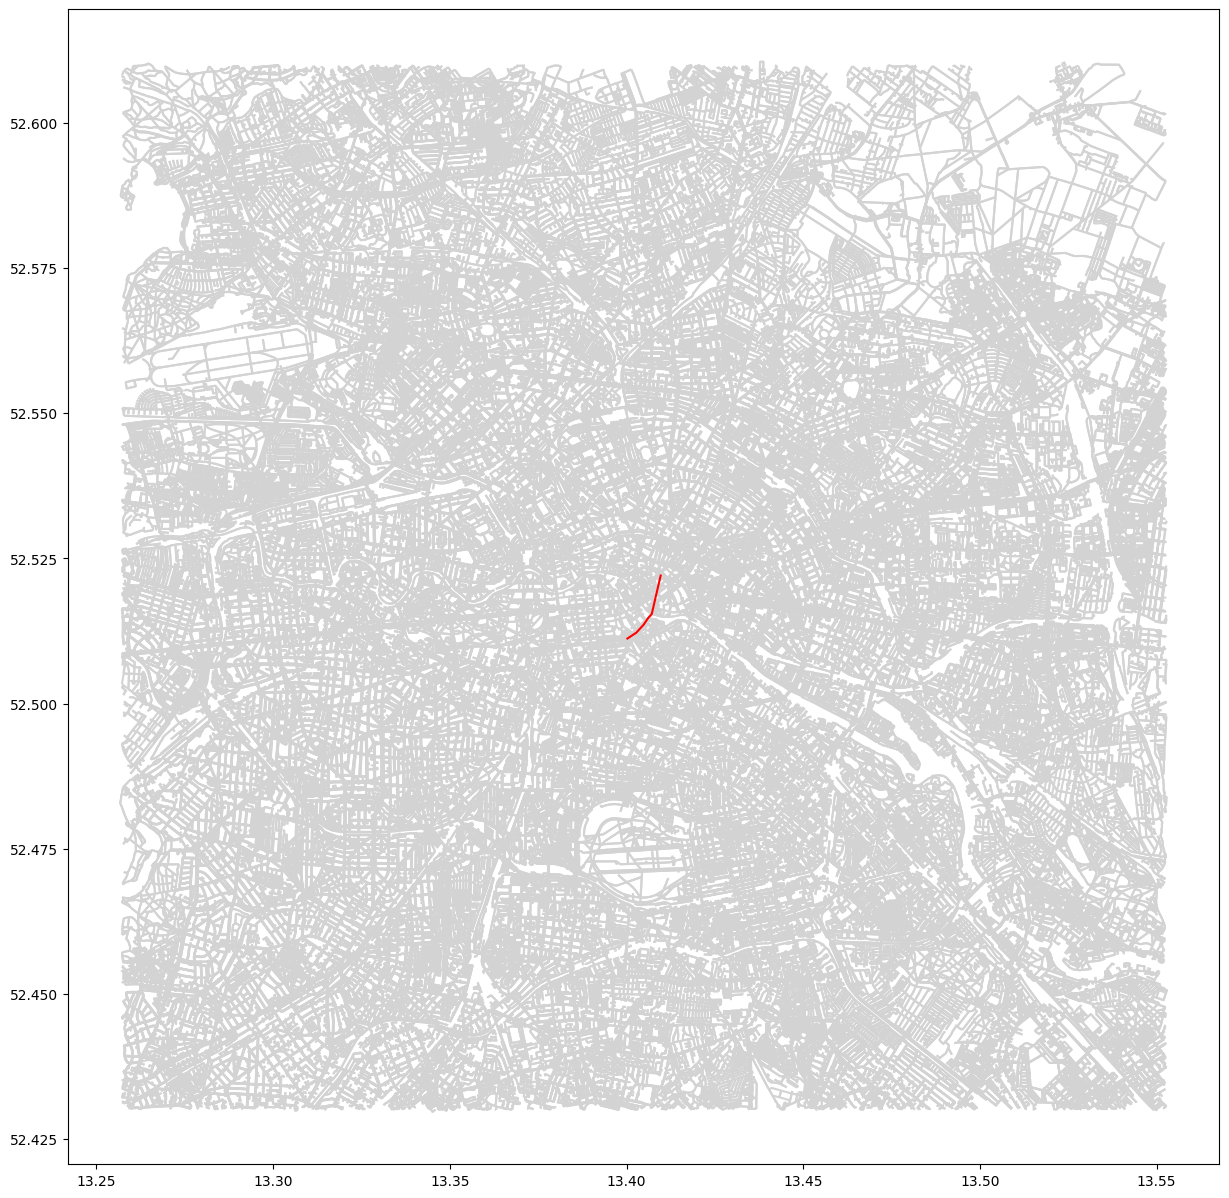

In [5]:
import pandas as pd 
import geopandas as gpd
from shapely import wkt 

pathlet_number = 10
#axis1 = osm.plot_graph(berlin_rn, node_size=0,edge_linewidth=0.09, bgcolor='white', show=True)
berlin_gdf = osm.convert.graph_to_gdfs(berlin_rn) #set CRS
#ax1 = berlin_gdf[0].plot(marker='o', markersize=0.01, color='lightgrey', zorder=2)
ax1 = berlin_gdf[1].plot(edgecolor='lightgray', zorder=1, figsize=(20, 15))
t = load_trajectory_from_file("./berlin/merged.txt")

#print(t.beginnings)
pathlet_beginning = 0
pathlet_end = 5
pathlet_mother = 3
print(t.beginnings)
l = t.get_pathlet_points(pathlet_beginning,pathlet_end, pathlet_mother)
print(get_polyline_string(l))
# create dataframe of the 2 polygons
d = {'col1': range(0, 1), 'wkt': [get_polyline_string(l)]}
df = pd.DataFrame( data=d )

# make geo-dataframe from it
geometry = [wkt.loads(pgon) for pgon in df.wkt]
gdf2 = gpd.GeoDataFrame(df, \
                   crs={'init': 'epsg:4326'}, \
                   geometry=geometry)

# plot it as red polygons
gdf2.plot(ax=ax1, color='red', zorder=5)


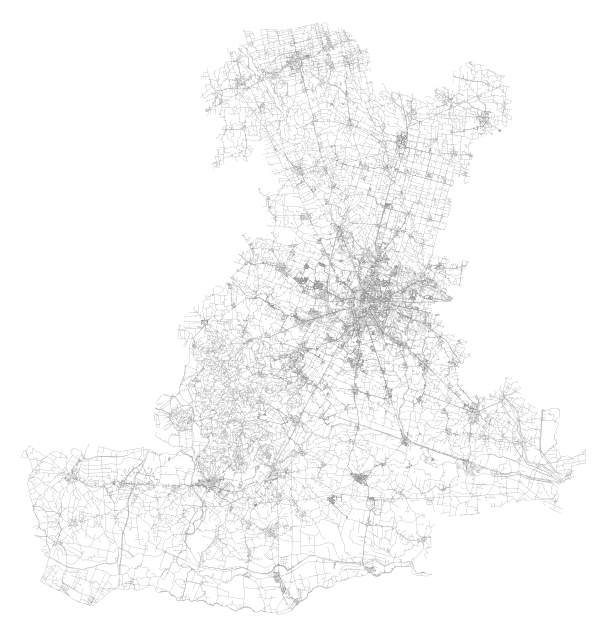

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
osm.plot_graph(padova_rn, node_size=0, edge_linewidth=0.09, bgcolor='white', show=True)